# Cargamos librerías

In [29]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Cargamos DB

In [77]:
# Cargar y preparar dataset
df = pd.read_csv("HDHI_Admission_data.csv")

# Convertir columna a datetime de manera automática
df["D.O.A"] = pd.to_datetime(df["D.O.A"], errors="coerce")

# Crear conteo diario de pacientes
daily = df.groupby(df["D.O.A"].dt.date).size().reset_index(name="patients")
daily["D.O.A"] = pd.to_datetime(daily["D.O.A"])

# Ordenar por fecha
daily = daily.sort_values("D.O.A").reset_index(drop=True)

print(daily.head())

       D.O.A  patients
0 2017-01-04         1
1 2017-01-10         2
2 2017-01-11         2
3 2017-01-12        11
4 2017-02-04         2


In [79]:
# Variables temporales
daily["dayofweek"] = daily["D.O.A"].dt.dayofweek
daily["month"] = daily["D.O.A"].dt.month
daily["day"] = daily["D.O.A"].dt.day
daily["weekofyear"] = daily["D.O.A"].dt.isocalendar().week

# Lags (fundamental en series temporales)
# lag_1 Número de pacientes del día anterior
# lag_7 número de pacientes hace 7 días (misma semana, patrón semanal)

daily["lag_1"] = daily["patients"].shift(1)
daily["lag_7"] = daily["patients"].shift(7)
daily["rolling_mean_7"] = daily["patients"].rolling(7).mean()

daily = daily.dropna()
print("Filas totales después de dropna:", daily.shape[0])

Filas totales después de dropna: 720


# Dividimos en X e y train y test

In [80]:
features = [
    "dayofweek",
    "month",
    "day",
    "weekofyear",
    "lag_1",
    "lag_7",
    "rolling_mean_7"
]

# Después de calcular lags y dropna
X = daily.drop(columns=["patients", "D.O.A"])
y = daily["patients"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False  # shuffle=False mantiene el orden temporal
)

#print(X_train.shape, X_test.shape)
#print(y_train.shape, y_test.shape)


# Evaluamos el modelo

In [81]:
model = RandomForestRegressor(
    n_estimators=500,
    max_depth=12,
    random_state=42
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

# Evaluar
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("RESULTADOS:")
print(f"MAE: {mae:.2f} pacientes")
print(f"RMSE: {rmse:.2f} pacientes")

RESULTADOS:
MAE: 4.51 pacientes
RMSE: 6.39 pacientes


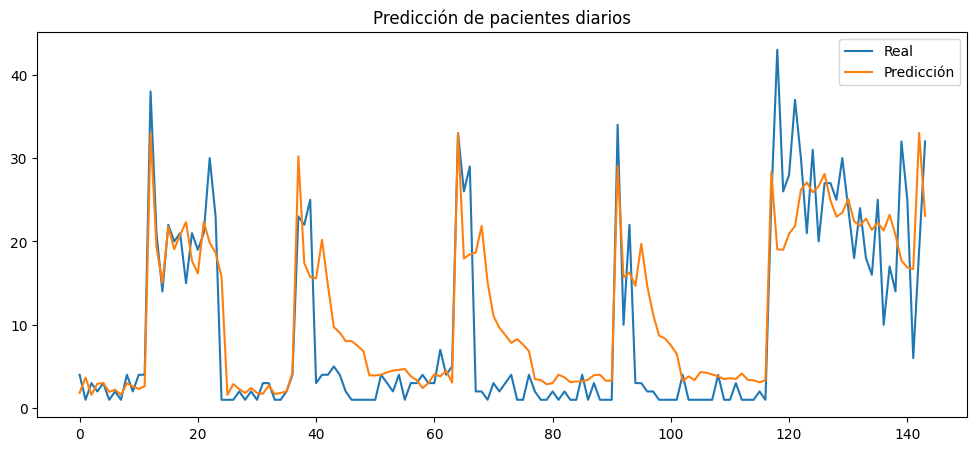

In [82]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Real")
plt.plot(predictions, label="Predicción")
plt.legend()
plt.title("Predicción de pacientes diarios")
plt.show()

# modelo SARIMAX

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error

# Cargar y preparar dataset
df = pd.read_csv("HDHI_Admission_data.csv")

# Convertir columna a datetime de manera automática
df["D.O.A"] = pd.to_datetime(df["D.O.A"], errors='coerce')  # convierte y pone NaT si falla

# Crear conteo diario de pacientes
daily = df.groupby(df["D.O.A"].dt.date).size().reset_index(name="patients")
daily["D.O.A"] = pd.to_datetime(daily["D.O.A"])
daily = daily.sort_values("D.O.A").reset_index(drop=True)

# Poner índice de fecha con frecuencia diaria
daily.set_index("D.O.A", inplace=True)

In [59]:
# Crear features temporales opcionales
daily["dayofweek"] = daily.index.dayofweek
daily["month"] = daily.index.month
daily["weekofyear"] = daily.index.isocalendar().week

# Lags y rolling mean
daily["lag_1"] = daily["patients"].shift(1)
daily["lag_7"] = daily["patients"].shift(7)
daily["rolling_mean_7"] = daily["patients"].rolling(7).mean()

# Después de lags, eliminar primeras filas con NaN
print("Total de NaNs:", daily["patients"].isna().sum())
#daily = daily.dropna()

Total de NaNs: 0


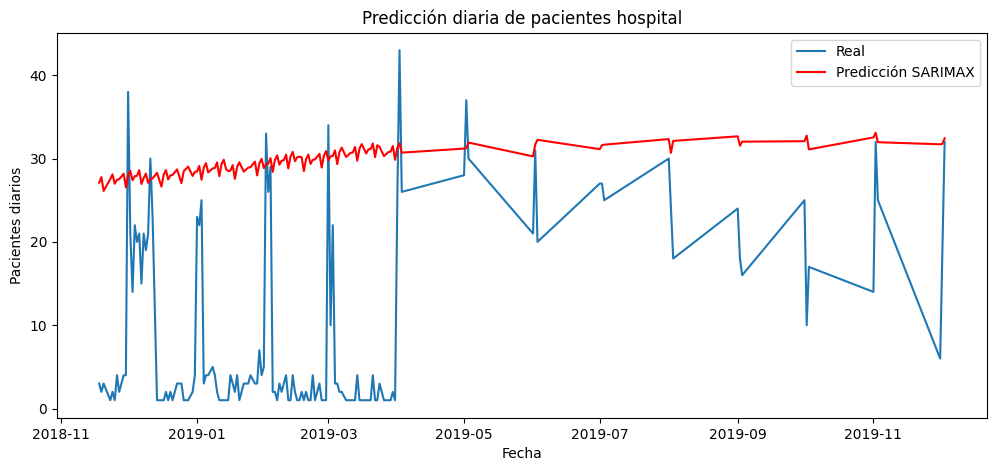

In [83]:
# Gráfico
plt.figure(figsize=(12,5))
#plt.plot(train.index, train, label="Entrenamiento")
plt.plot(test.index, test, label="Real")
plt.plot(test.index, preds, label="Predicción SARIMAX", color='red')
plt.xlabel("Fecha")
plt.ylabel("Pacientes diarios")
plt.title("Predicción diaria de pacientes hospital")
plt.legend()
plt.show()

MAE: 3.031110922794405
RMSE: 6.998150686723967


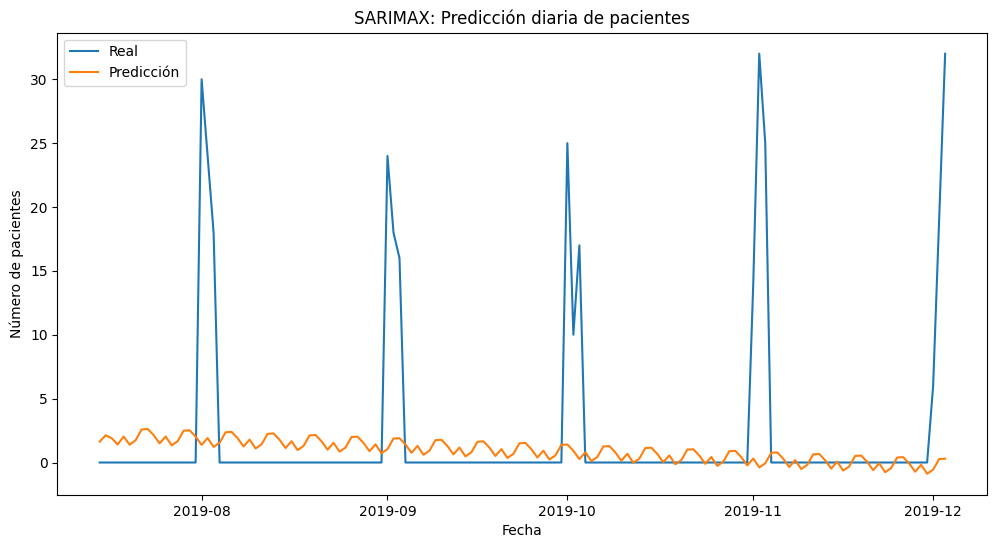

In [69]:
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt

#  Ordenar por fecha
daily = daily.sort_index()

#  Crear índice diario completo desde la primera hasta la última fecha
full_index = pd.date_range(start=daily.index.min(), end=daily.index.max(), freq='D')

# Reindexar la serie 'patients', rellenando días faltantes con 0
y_full = daily["patients"].reindex(full_index, fill_value=0)

# Split en entrenamiento y test (últimos 142 días para test)
train = y_full[:-142]
test = y_full[-142:]

# Entrenar SARIMAX con estacionalidad semanal
model = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,7)
)
model_fit = model.fit(disp=False)

# Predecir
preds = model_fit.forecast(steps=len(test))

# Evaluar
mae = mean_absolute_error(test, preds)
rmse = np.sqrt(np.mean((test - preds)**2))

print("MAE:", mae)
print("RMSE:", rmse)

# Graficar resultados
plt.figure(figsize=(12,6))
plt.plot(test.index, test, label="Real")
plt.plot(test.index, preds, label="Predicción")
plt.title("SARIMAX: Predicción diaria de pacientes")
plt.xlabel("Fecha")
plt.ylabel("Número de pacientes")
plt.legend()
plt.show()

In [76]:
import pandas as pd

# Supongamos que tu columna de fecha se llama 
df['D.O.A'] = pd.to_datetime(df['D.O.A'])
df = df.set_index('D.O.A').sort_index()

# Revisar si hay días faltantes
missing_days = pd.date_range(df.index.min(), df.index.max()).difference(df.index)
print(missing_days)

DatetimeIndex(['2017-01-05', '2017-01-06', '2017-01-07', '2017-01-08',
               '2017-01-09', '2017-01-13', '2017-01-14', '2017-01-15',
               '2017-01-16', '2017-01-17',
               ...
               '2019-11-21', '2019-11-22', '2019-11-23', '2019-11-24',
               '2019-11-25', '2019-11-26', '2019-11-27', '2019-11-28',
               '2019-11-29', '2019-11-30'],
              dtype='datetime64[ns]', length=337, freq=None)
